# COGS 108 - Data Checkpoint

- Amelia Fletcher: Conceptualization, Background research, Writing - original draft, review & editing
- Beren Gao: Conceptualization, Methodology, Experimental Investigation, Analysis, Writing - original draft, review & editing
- Neil Pakinggan: Software, Visualization, Conceptualization, Data curation, Background research
- Monica Sandoval: Conceptualization, Writing - original draft, review & editing
- Julia Zhang: Analysis, Visualization, Conceptualization, Writing - original draft, review & editing

## Research Question

To what extent can bot-generated and human-generated comments be distinguished using predefined linguistic features (e.g. wording, syntax) and behavioral features (e.g. posting frequency, response latency)?

## Background and Prior Work

Since the rise of AI, online discussion forums (i.e., Reddit, Twitter) have seen an increase in bots that mimic or imitate human social interactions, particularly participating in conversations and discourse of various topics in the comment sections of threads. Such mimicry blurs the line between human-generated internet discussion versus AI bot-generated discussion, and what is real versus what is fake. This raises the question: To what extent can bot-generated and human-generated Reddit comments be distinguished using predefined linguistic features (e.g., wording, syntax) and behavioral features (e.g., posting and response frequency)? 

Previous research has already been done regarding this topic; for example, the world’s largest Turing test study from AI lab AI21, involving 1.5 million human participants, tasked humans with discerning whether the user they’re chatting with was human or AI. This resulted in correct guesses that they were interacting with AI in “60% of conversations,” a statistic that researchers claimed was “not much higher than chance.”<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) Alongside AI21’s test study, different research publications have noted that in subreddits, human user posts contained distinct features such as grammatical discrepancies, internet jargon, and erroneous capitalization, whilst ChatGPT-4 generated texts contained impeccable grammar, a complex syntactical structure, and overused emojis.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2) This leads to a possible method of distinguishing an AI from human users: finding the difference of “lexical richness” and “logical soundness” between LLM-authored posts compared to human ones.<a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3) 


1. <a name="cite_note-1"></a> [^](#cite_ref-1) Zhang, M. (9 Jun 2023) In Largest-Ever Turing Test, 1.5 Million Humans Guess Little Better Than Chance. *Artisana*. https://www.artisana.ai/articles/in-largest-ever-turing-test-1-5-million-humans-guess-little-better-than
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Arcenal, E. & Capistrano, L. & Guzman, M. & Forrosuelo, M. & Miranda, J. (Sep 2024) Comparative Analysis of Reddit Posts and ChatGPT-Generated Texts’ Linguistic Features: A Short Report on Artificial Intelligence’s Imitative Capabilities. *International Journal of Multidisciplinary: Applied Business and Education*.
https://doi.org/10.11594/ijmaber.05.09.063.
3. <a name="cite_note-3"></a> [^](#cite_red-3) Dönmez E. & Maurer M. & Lapesa G. & Falenska A. (Nov 2025) AI Argues Differently: Distinct Argumentative and Linguistic Patterns of LLMs in Persuasive Contexts *Proceedings of the 2025 Conference on Empirical Methods in Natural Language Processing*
https://aclanthology.org/2025.emnlp-main.1755.pdf

## Hypothesis


We hypothesize that __bot-generated comments are distinguishable from human-generated comments__ as they exhibit systematic differences in *linguistic and behavioral patterns*. We assume that these differences are measurable using predefined quantities, with bots tending to exhibit more repetitive syntax, distinct wording patterns, higher posting frequency, and shorter response latency compared to humans. 

This prediction is based on prior research implying that artificial intelligence (AI) often displays systematic linguistic features and temporal behaviors that differ from humans, who tend to produce more variable language, including grammatical discrepancies and slang, and irregular posting patterns. 

As a result, we predict a strong correlation between the type of author (bot vs human) and their commenting habits online.

# Data overview

## Dataset #1 (The "Dead Internet" Theory: Reddit Bot vs. Human)
  - Link to the dataset: https://www.kaggle.com/datasets/nudratabbas/the-dead-internet-theory-reddit-bot-vs-human
  - Number of observations: 500 observations 
  - Number of variables: 11 variables
      - `account_age_days` which displays how old a certain account is on Reddit in days numerically, important to distinguish a bot from a human with "throwaway" bot accounts having a shorter or lower account age compared to human accounts.
      - `avg_word_length` which displays the average characters per word in a numerical float, with synthetically generated bot comments/content, also known as "slop" often has higher/lower variance as described in the dataset in Kaggle.
      - `reply_delay_seconds` is a numeric variable that finds the time difference between the original post and the comment associated, which often signal automation the lower the reply is (usually <5 seconds). 
  - Possible shortcomings: The lack of overlap between variables may make it hard to find other correlations in other datasets.

## Dataset #2 (AI_vs_Human_combined)
  - Link to dataset: https://www.kaggle.com/datasets/farwa99/ai-vs-human-combined
  - Number of observations: 717,694 observations
  - Number of variables: 2 variables
    -  `text` shows the raw text content generated by either a human or a bot.
    -  `label` is a binary classification label. 0 for human-written, 1 for AI-generated.
    -  `word_count` shows the number of words in each text.
  - Possible shortcomings:
    - The dataset combines texts from multiple sources which may vary in topic, length and linguistic style. This may introduce heterogeneity where features such as common words might reflect the result of source combination.
    - The dataset is shuffled to eliminate the effect of ordering bias. However, this does not mitigate sampling bias.
    - Only text and label columns are retained, where the author, source, and timestamps of the text are lost. 


The two datasets will be combined carefully to answer our research question through two models analyzing linguistic features and behavioral features of text, allowing a comprehensive assessment of the differences between bot-generated and human-written texts. 

The first dataset provides behavioral features, such as account age, reply delay, and average word length. Those features are critical to identifying automated activity and distinguishing bots from humans based on posting patterns and account characteristics. The second dataset provides raw text, labels, and word counts, allowing the extraction of linguistic features such as syntax, vocabulary, and text complexity. 

By integrating behavioral and linguistic features, we can evaluate the extent to which bot-generated and human-generated comments can be distinguished, while accounting for potential variability across sources and feature availability.

In [11]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [12]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://drive.google.com/uc?export=download&id=1SXcJvoOo5uEGYC9gJBDOOC_fSFXXb4ht', 'filename':'reddit_dead_internet_analysis_2026.csv'},
    #{ 'url': 'https://drive.google.com/uc?export=download&id=1yKcxExZjCLTvs0_lJ8QoF9Ej9e4Oee1l', 'filename':'balanced_ai_human_prompts.csv'}
    # waiting for second df to use 
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress: 100%|██████████████████| 1/1 [00:01<00:00,  1.14s/it]

Successfully downloaded: reddit_dead_internet_analysis_2026.csv


### Reddit Dead Internet Analysis in 2026

Important metrics of this dataset include: `account_age_days` which displays how old a certain account is on Reddit in days numerically, important to distinguish a bot from a human with "throwaway" bot accounts having a shorter or lower account age compared to human accounts. `avg_word_length` which displays the average characters per word in a numerical float, with synthetically generated bot comments/content, also known as "slop" often has higher/lower variance as described in the dataset in Kaggle. `reply_delay_seconds` is a numeric variable that finds the time difference between the original post and the comment associated, which often signal automation the lower the reply is (usually <5 seconds). `is_bot_flag` being a boolean variable that shows whether an account is a bot or human in order to distinguish and find patterns/correlations between the given variables and accounts. 

A concern of this dataset can be the lack of variables that can be used to find other correlations in other datasets, aka the lack of overlapping variables between this dataset and another possibly. This is usable but may be hard to get a good comparison if our model is more powerful predicting off of other factors that are not listed in this dataset necessarily.

In [14]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Rows: 500
Columns: 11
Cells: 5,500

number of outliers from iqr test:
account_age_days         :  0 outlier(s)
user_karma               :  0 outlier(s)
reply_delay_seconds      :  0 outlier(s)
sentiment_score          :  0 outlier(s)
avg_word_length          :  0 outlier(s)
bot_probability          : 12 outlier(s)

12 flagged rows
 account_age_days  user_karma  reply_delay_seconds  sentiment_score  avg_word_length  bot_probability
                1       27834                    8            -0.88             5.70            0.358
                1       11730                    2            -0.47             6.60            0.465
                1       39727                    3             0.17             6.11            0.422
                3       46307                    1            -0.08             6.68            0.434
               27       15472                    1             0.95             7.18            0.358
                5       32711                    1    

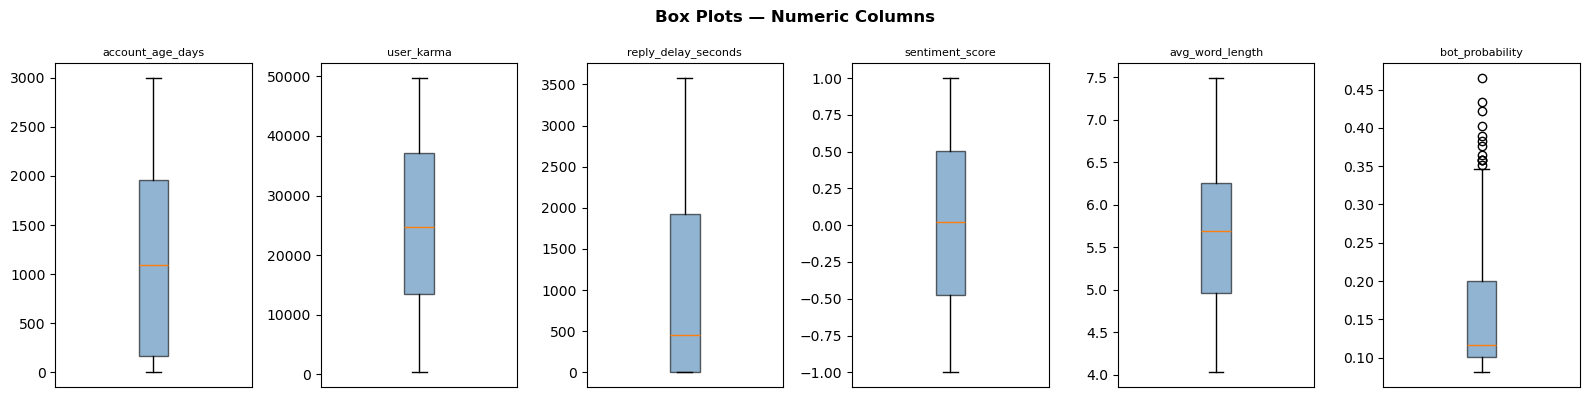


=== numbers summary ===
       account_age_days    user_karma  reply_delay_seconds  sentiment_score  \
count        500.000000    500.000000           500.000000       500.000000   
mean        1157.624000  25248.198000          1030.700000         0.014980   
std          951.766304  14122.969163          1184.411096         0.581127   
min            1.000000    308.000000             1.000000        -1.000000   
25%          163.000000  13427.250000             7.000000        -0.472500   
50%         1092.500000  24778.500000           459.000000         0.020000   
75%         1960.000000  37111.500000          1925.000000         0.502500   
max         2996.000000  49734.000000          3577.000000         1.000000   

       avg_word_length  bot_probability  
count       500.000000       500.000000  
mean          5.654300         0.156530  
std           0.895203         0.074555  
min           4.030000         0.081000  
25%           4.967500         0.101000  
50%        

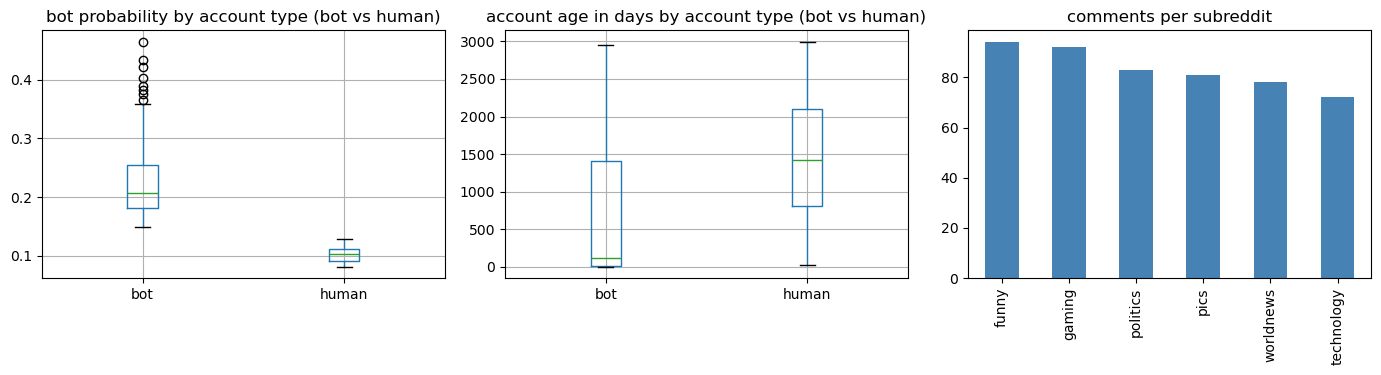

In [15]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE

# load dataset
reddit_df = pd.read_csv('data/00-raw/reddit_dead_internet_analysis_2026.csv')

# demonstrate dataset size
print(f"\nRows: {reddit_df.shape[0]:,}")
print(f"Columns: {reddit_df.shape[1]}")
print(f"Cells: {reddit_df.size:,}")

# remove missing data, rows, etc.
cleaned_reddit_df = reddit_df.dropna(how = 'all')

# finding suspicious entries, outliers, etc.
numeric_cols = ['account_age_days', 'user_karma', 'reply_delay_seconds', 'sentiment_score', 'avg_word_length', 'bot_probability']

# iqr: flag values outside [Q1 - 1.5*iqr, Q3 + 1.5*iqr] in order to find the outliers
outlier_flags = pd.DataFrame(False, index = reddit_df.index, columns = numeric_cols)
print("\nnumber of outliers from iqr test:")
for col in numeric_cols:
    q1, q3 = reddit_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    flag = (reddit_df[col] < q1 - 1.5*iqr) | (reddit_df[col] > q3 + 1.5*iqr)
    outlier_flags[col] = flag
    print(f"{col:<25}:{flag.sum():>3} outlier(s)")

# mark rows with any outlier
reddit_df['is_outlier'] = outlier_flags.any(axis=1)

# check the flagged rows
outlier_rows = reddit_df[reddit_df['is_outlier']][numeric_cols]
print(f"\n{len(outlier_rows)} flagged rows")
print(outlier_rows.to_string(index=False))

print('\nall 12 outliers are in bot_probability (>0.35) and share a clear pattern: very new accounts (age 1–27 days) are labelled as bots, we can ignore this due to common sense')

# is_bot_flag must agree with bot_type_label
inconsistent = reddit_df[
    ((reddit_df['is_bot_flag'] == True)  & (reddit_df['bot_type_label'] == 'None (Human)')) |
    ((reddit_df['is_bot_flag'] == False) & (reddit_df['bot_type_label'] != 'None (Human)'))
]

if (len(inconsistent) != 0):
    print('\ninconsistency found')
else:
    print('\nno inconsistencies, is_bot_flag and bot_type_label are redundant and should be removed')

# box plots
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(reddit_df[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col, fontsize=8)
    ax.set_xticks([])
plt.suptitle("Box Plots — Numeric Columns", fontweight='bold')
plt.tight_layout()
plt.show()

# saving interim to data/01-interim
reddit_df.to_csv('data/01-interim/reddit_analysis_2026_pre_wrangled.csv', index = False)

# tidying up entries, putting them into categories, we don't need what kind of bot they are

cleaned_reddit_df = reddit_df.dropna(how = 'all').copy()

account_map = {
    'AI Summarizer':'bot',
    'Reprint Bot':'bot',
    'Engagement Farmer':'bot',
    'None (Human)':'human'
}

cleaned_reddit_df['account_type'] = cleaned_reddit_df['bot_type_label'].map(account_map)

# removing variables we don't need/are redundant
cleaned_reddit_df.drop(['bot_type_label', 'is_bot_flag', 'contains_links'], axis = 1, inplace = True)

# size of dataset
cleaned_reddit_df.size
cleaned_reddit_df

# load data into data/02-processed
cleaned_reddit_df.to_csv('data/02-processed/reddit_analysis_2026_wrangled.csv', index = False)

# summary stats that may be important
print("\n=== numbers summary ===")
print(cleaned_reddit_df.select_dtypes('number').describe())

print("\n=== bot probability by account type ===")
print(cleaned_reddit_df.groupby('account_type')['bot_probability'].describe())

print("\n=== account age (days) by account type ===")
print(cleaned_reddit_df.groupby('account_type')['account_age_days'].describe())

print("\n=== subreddit distribution ===")
print(cleaned_reddit_df['subreddit'].value_counts())

# summary visualisations
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cleaned_reddit_df.boxplot(column='bot_probability', by='account_type', ax=axes[0])
axes[0].set_xlabel('')
plt.sca(axes[0]); plt.title('bot probability by account type (bot vs human)')

cleaned_reddit_df.boxplot(column='account_age_days', by='account_type', ax=axes[1])
axes[1].set_xlabel('')
plt.sca(axes[1]); plt.title('account age in days by account type (bot vs human)')

cleaned_reddit_df['subreddit'].value_counts().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('comments per subreddit')
axes[2].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

### Dataset #2 

See instructions above for Dataset #1.  Feel free to keep adding as many more datasets as you need.  Put each new dataset in its own section just like these. 

Lastly if you do have multiple datasets, add another section where you demonstrate how you will join, align, cross-reference or whatever to combine data from the different datasets

Please note that you can always keep adding more datasets in the future if these datasets you turn in for the checkpoint aren't sufficient.  The goal here is demonstrate that you can obtain and wrangle data.  You are not tied down to only use what you turn in right now.

In [17]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE

# path to your manually downloaded file
text_df = pd.read_csv('data/00-raw/dataset_2.csv')

# demonstrate dataset size
print(f"\nRows: {text_df.shape[0]:,}")
print(f"Columns: {text_df.shape[1]}")
print(f"Cells: {text_df.size:,}")
print(f" Columns index:{text_df.columns}")


Rows: 717,684
Columns: 3
Cells: 2,153,052
 Columns index:Index(['text', 'label', 'word_count'], dtype='object')


In [18]:
# demonstrate any row with a missing value
print("\nMissing values per column:")
print(text_df.isna().sum())

# remove missing data, rows, etc.
cleaned_text_df = text_df.dropna().copy()

# make sure data types in each column is consistent
cleaned_text_df['label'] = cleaned_text_df['label'].astype(int)
cleaned_text_df['word_count'] = cleaned_text_df['word_count'].astype(int)


Missing values per column:
text          1
label         0
word_count    1
dtype: int64


In [23]:
text_wordcount = cleaned_text_df['word_count']

# iqr: flag values outside [Q1 - 1.5*iqr, Q3 + 1.5*iqr] in order to find the outliers
q1 = text_wordcount.quantile(0.25)
q3 = text_wordcount.quantile(0.75)
iqr = q3 - q1

outlier_flags = (text_wordcount < q1 - 1.5*iqr) | (text_wordcount > q3 + 1.5*iqr)

# mark rows with outliers
cleaned_text_df['is_outlier'] = outlier_flags

# flagged rows
num_outliers = outlier_flags.sum()
print(f"\nNumber of outliers in word_count: {num_outliers}")

print("\nFlagged outliers are texts with extreme word counts. Those are removed for easier analysis.")

# remove outliers
cleaned_text_df_no_outliers = cleaned_text_df[~cleaned_text_df['is_outlier']].copy()
print(f"\nDataset size after removing outliers: {cleaned_text_df_no_outliers.shape[0]} rows")

# saving interim to data/01-interim
cleaned_text_df.to_csv('data/01-interim/dataset_2_cleaned.csv', index=False)
# saving processed data to data/02-processed
cleaned_text_df_no_outliers.to_csv('data/02-processed/dataset_2_final.csv', index=False)


Number of outliers in word_count: 37140

Flagged outliers are texts with extreme word counts. Those are removed for easier analysis.

Dataset size after removing outliers: 680543 rows


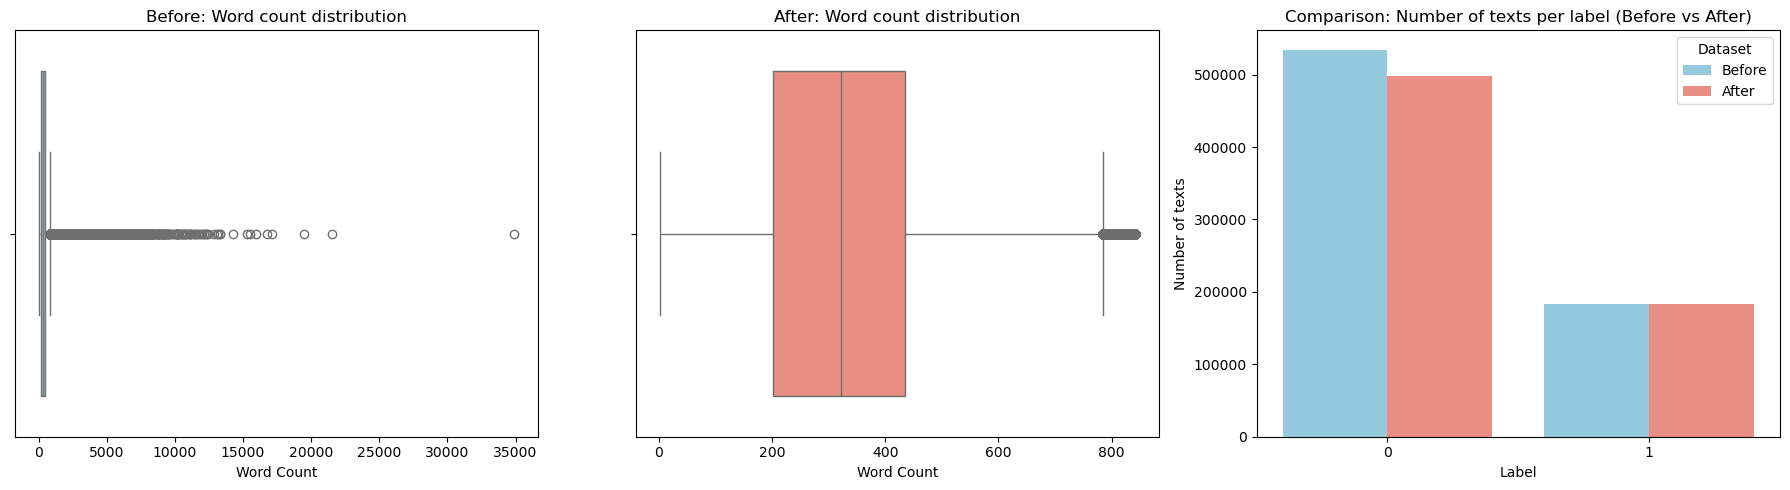

In [47]:
# summary visualisations before and after removing outliers in word count
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# before removing outliers: word count distribution
sns.boxplot(x='word_count', data=cleaned_text_df, color='skyblue', ax=axes[0])
axes[0].set_title("Before: Word count distribution")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("")

# after removing outliers: word count distribution
sns.boxplot(x='word_count', data=cleaned_text_df_no_outliers, color='salmon', ax=axes[1])
axes[1].set_title("After: Word count distribution")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("")

# comparison of labels before vs after outlier removal
before_df = cleaned_text_df.copy()
before_df['dataset'] = 'Before'
after_df = cleaned_text_df_no_outliers.copy()
after_df['dataset'] = 'After'
combined_df = pd.concat([before_df, after_df])

sns.countplot(x='label', hue='dataset', data=combined_df, palette=['skyblue','salmon'], ax=axes[2])
axes[2].set_title("Comparison: Number of texts per label (Before vs After)")
axes[2].set_xlabel("Label")
axes[2].set_ylabel("Number of texts")
axes[2].legend(title='Dataset')

plt.tight_layout()
plt.show()

## Ethics 


[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> Reddit's TOS includes that they have the "right for us to make Your Content available for syndication, broadcast, distribution, or publication by other companies, organizations, or individuals who partner with Reddit." While none of our datasets themselves  seem to be Reddit-sponsored or partnered sources, the fact remains that Reddit is a public forum, and most content posted there is public.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> As the data was not collected by us directly, we cannot confirm or deny this. The groups ('subreddits') these data were collected from may be biased in what comments are allowed or visibile in each, based on group culture or rules. Stratifying based on group or group type might help mitigate these biases.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

> The data is easily anonymizable by removing account information (names, ids) before performing any analysis.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

> We can test within specific groups in the common scenario that the group's population does not match that of Reddit overall, then compare results relative to the group's population, rather than the population of all data.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

> As the data has already been collected and any identifiable information removed, both concerns are resolved. For the repo specifically, it is protected by both account passwords and SSH keys.
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

> As the data is publically sourced and easily available, there is no reason for us to delete the data after usage. It will remain in the repo for ease of use.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

> We currently have no plans to do this. We also have no plans *not* to do this. Personally, I would like to ask a Reddit engineer or moderator how things are, but I'm unsure if I can get a hold of any.
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

> We currently do not see any potential factors of bias in the data after a detailed review. However, such biases are difficult to spot in datasets focused purely on social media messages with lacking information about the life of the people who wrote them.
 - [ ] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

> We do not have representations right now. Will revisit after representations are created.
 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

> We can and will remove account ids, names, etc. before the analysis is performed.
 - [ ] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

> I sure hope it will be. Will revisit after analysis is complete.

### D. Modeling
> As we currently lack a model, this section will be left blank.
 - [ ] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
 - [ ] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [ ] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 - [ ] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [ ] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

### E. Deployment
> As we currently lack both a model to deploy and information to disseminate, this section will be left blank.
 - [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [ ] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?


## Team Expectations 

**COMMUNICATION**
* We can expect to communicate regularly through our Instagram group chat and check in with each other regarding progress and deadlines
* If confusion arises, we clear any misunderstandings by asking each other questions as soon as possible

**TONE**
* Firm yet reasonable, well-meaning criticism, and we should recognize that we are all here for the same goal/purpose in this project

**DECISION-MAKING**
* We will take into consideration everyone’s opinions and try to reach some sort of agreement or consensus of opinion when it comes to decisions.
* This can be similar to a group voting system
* We could also have people add to decisions with their ideas instead of it being set in stone

**TASKS AND EXPECTATIONS**
* Communicate precisely and explicitly with each other regarding our division of work and the role that we play transparently, so as not to cause any confusion.
* We will have each member have a specific role that they will fulfill throughout the project, listed at the top of this project proposal.

**CIRCUMSTANCES**
* We will respect each member's differing schedules and workloads as students.
* If in the case of a member not being able to keep up with set deadlines or their part in the project, they should always ask for help as early as possible or notify us when they think so (i.e., they have midterms to focus on at the end of the week)
* We can always have someone help out when needed to lighten the workload 

## Project Timeline Proposal


| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 2/7  |  5 PM | Gather dataset(s) that will help us answer our research question  | Explain how gathered datasets contribute to the project and answering our research question | 
| 2/11  |  4 PM | Begin collecting background research on our topic | Discuss collected research and begin narrowing down dataset(s) and background research | 
| 2/15  | 5 PM  | Write and edit data descriptions; begin discussing supporting data; look at issues raised from proj proposal  | Communicate data models and purposes in order to formulate proper descriptions; discuss data cleanliness and what needs to be completed before submission   |
| 2/18  | 6 PM  | Finalize datasets and descriptions; Submit Data Checkpoint w/ as much done as possible | Discuss finalization of datasets being used and ensure that the written descriptions provide ample information for their purpose    |
| 2/22  | 4 PM  | Beginning construction of visualization of AI patterns; visualize our findings; correct any errors or shortcomings after review | Discuss types of visualization that will be most effective for our project; disucss fixing areas that are lacking or need improvement  |
| 3/1  | 5 PM  | Continue constructing EDA section; finalize written portion of EDA | Explain written descriptions and context of EDA; clean up information |
| 3/4  | 5 PM  | Complete EDA; Submit EDA Checkpoint | Communicate any final changes necessary for EDA portion of project; begin discussion on finalizing project |
| 3/8  | 4 PM  | Write Abstract, Discussion, and Conclusion | Finalize changes on Abstract, Discussion, and Conclusion; discuss repeated areas and analysis further in the context of project overall, ensure everything still makes sense and finalize; discuss video filming and roles for filming  |
| 3/11  | 5 PM  | Film video | Discuss any necessary editing; finalize video and discuss end of project  |
| 3/18  | Before 11:59 PM  | Finalize everything | Turn in Final Project, Video, Team Eval Survey, and Post Course Survey |